# Task 1


--- Initial Data Inspection ---
Transaction columns and missing counts:
        column          dtype  n_missing  n_unique
          DATE datetime64[ns]          0       364
     STORE_NBR          int64          0       272
LYLTY_CARD_NBR          int64          0     72637
        TXN_ID          int64          0    263127
      PROD_NBR          int64          0       114
     PROD_NAME         object          0       114
           QTY          int64          0         6
     TOT_SALES        float64          0       112
Behaviour columns and missing counts:
          column  dtype  n_missing  n_unique
  LYLTY_CARD_NBR  int64          0     72637
       LIFESTAGE object          0         7
PREMIUM_CUSTOMER object          0         3


C:\Users\Administrator\AppData\Local\Temp\ipykernel_22420\1131015232.py:46: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tx['is_chips'] = tx['PROD_NAME'].str.contains(chips_pattern, na=False)


Detected chips rows: 179210 out of 264836
Transaction rows after removing salsa: 246742
Outlier Customer (226000) removed from tx and pb.
Transaction rows after QTY < 10 filter: 246740
Final analysis rows after filtering for explicit chips: 174819


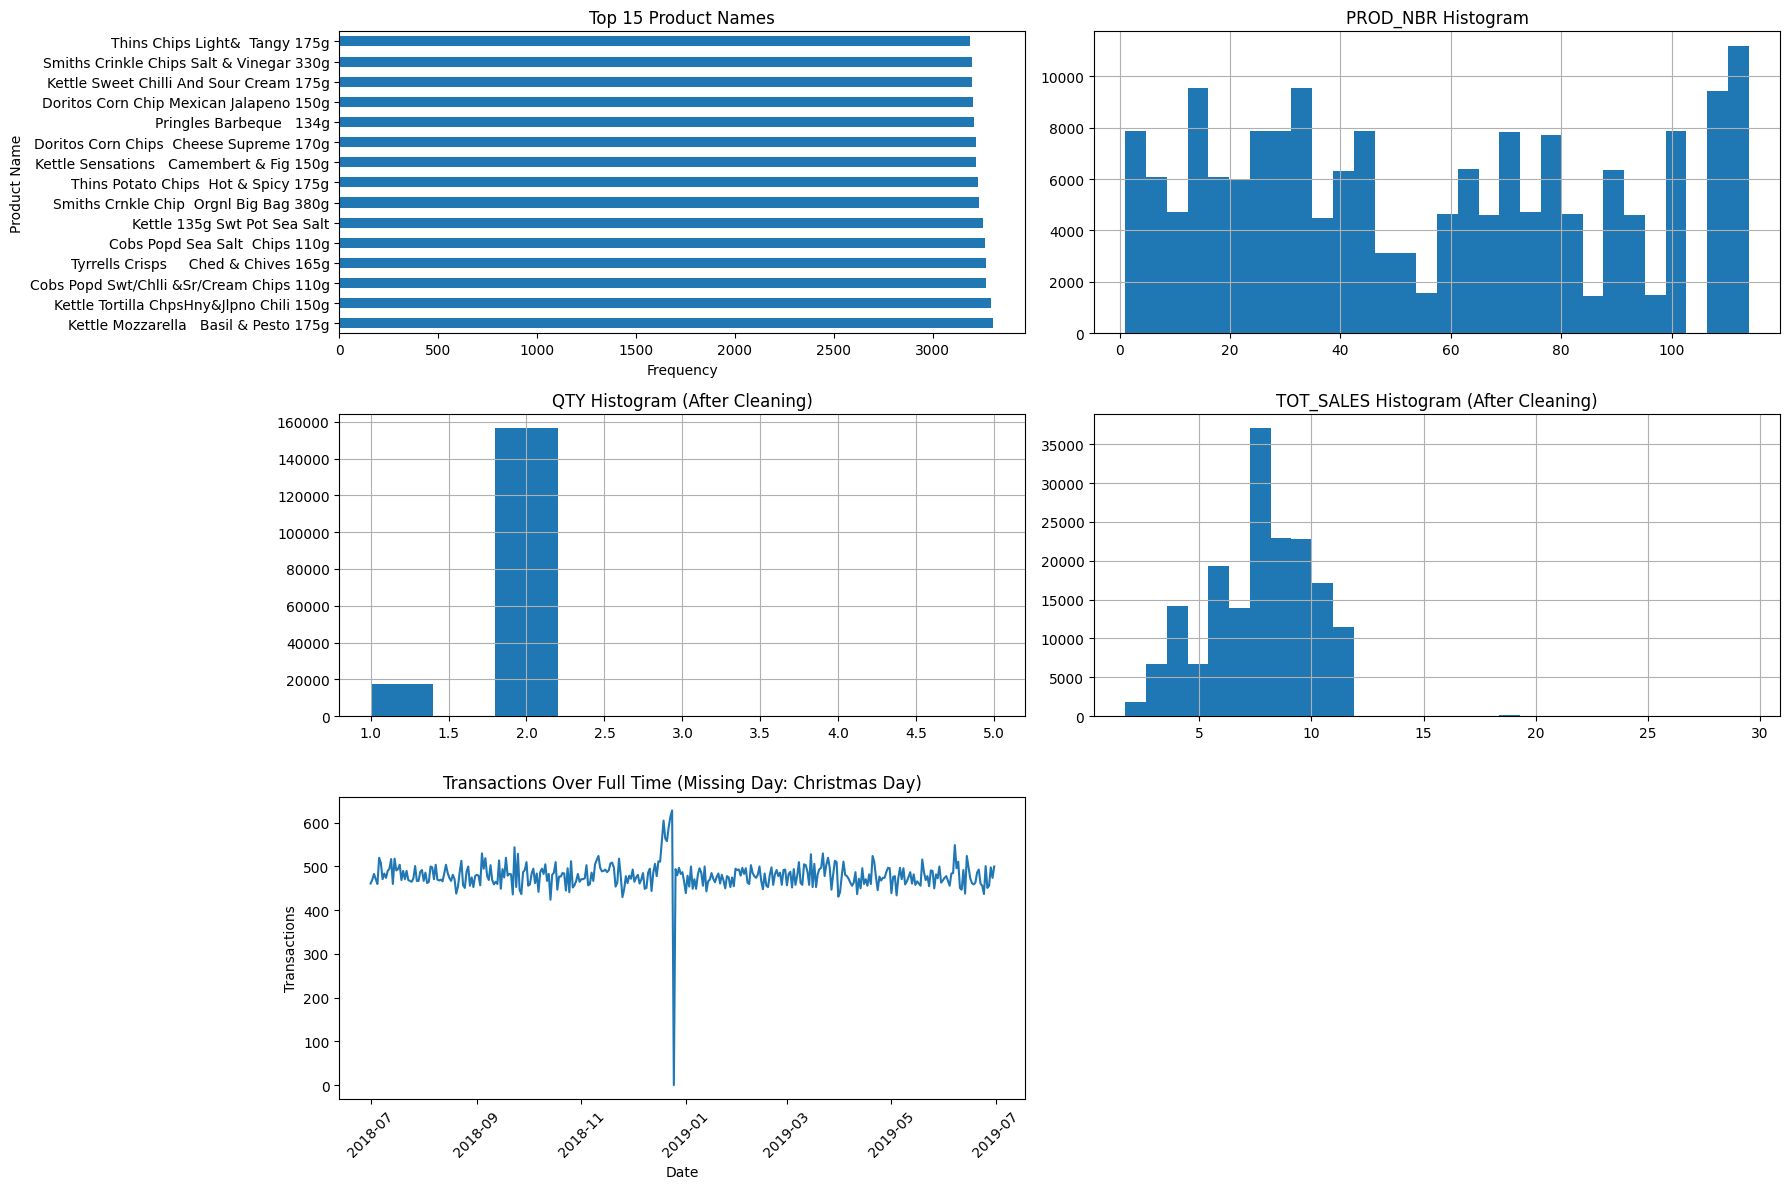

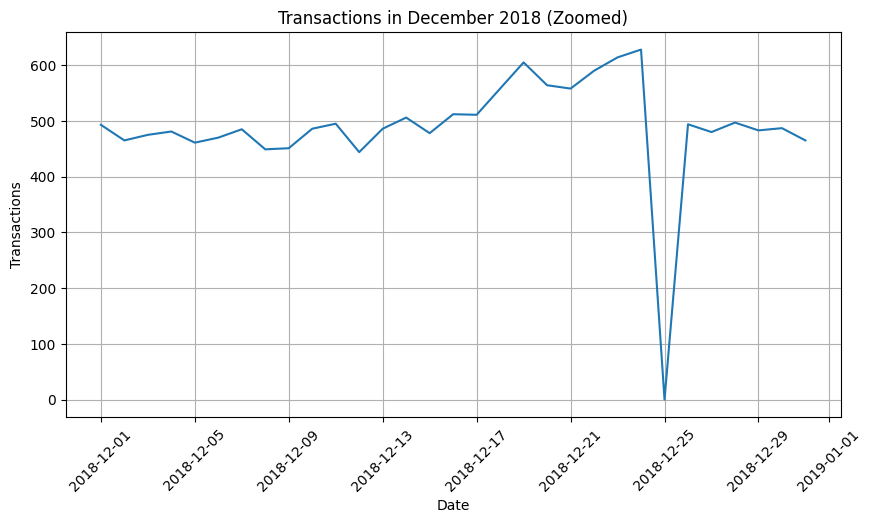

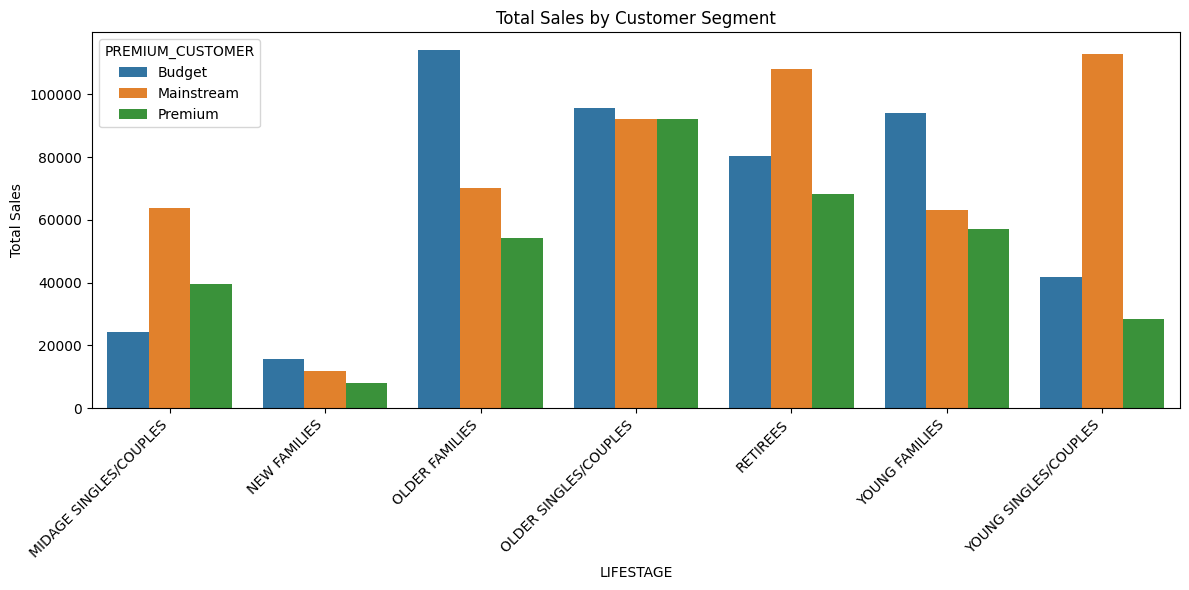

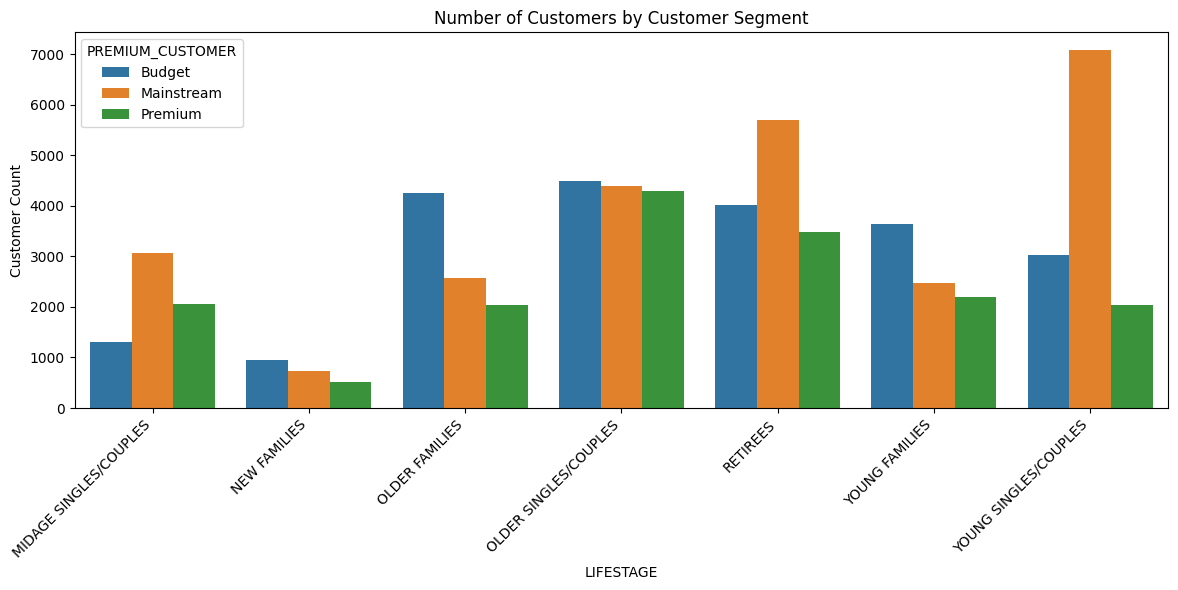

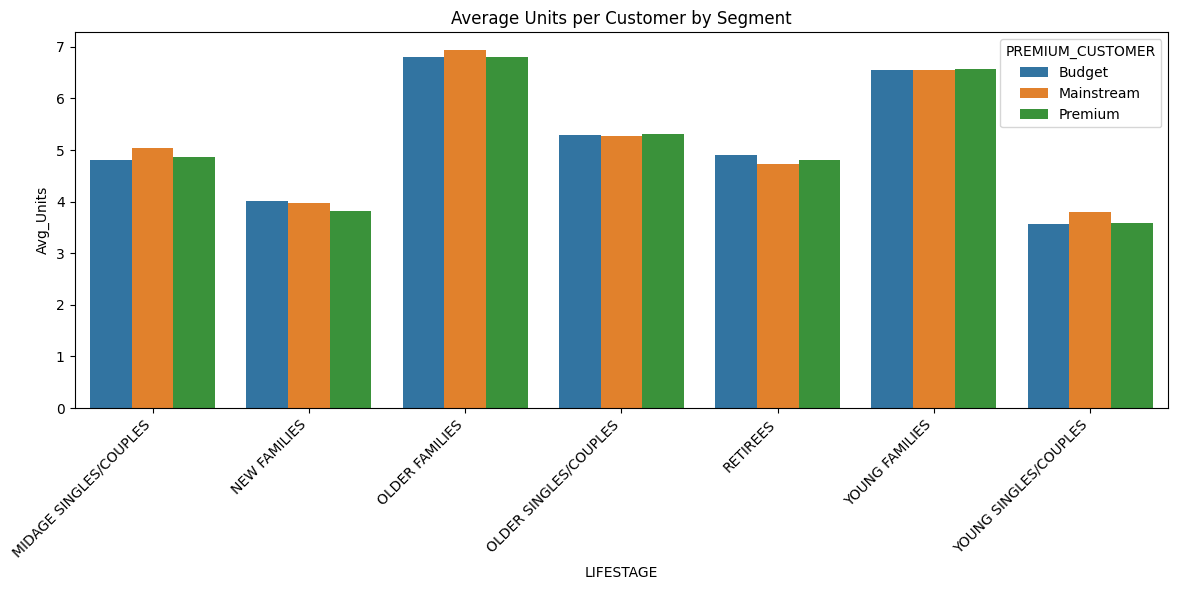

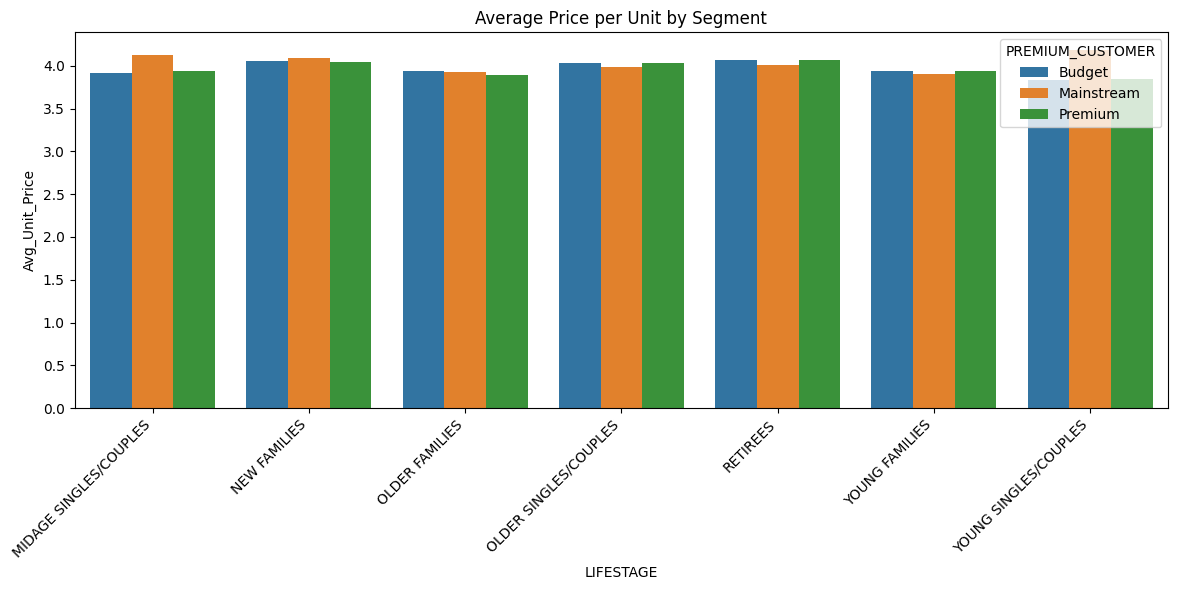


--- T-Test Results ---
T-statistic: 28.6648
P-value: 0.0000000000
The unit price for mainstream, young and mid-age singles and couples ARE significantly higher than that of budget or premium, young and midage singles and couples.

--- Brand Preference for Mainstream Young Singles/Couples (Top 5 Affinity Ratio) ---
          Target_Share  Other_Share  Affinity_Ratio
BRAND                                              
TYRRELLS      0.042696     0.036321        1.175510
TWISTIES      0.062078     0.053355        1.163471
DORITOS       0.143192     0.124531        1.149848
KETTLE        0.265140     0.233556        1.135229
PRINGLES      0.159677     0.142134        1.123430

[INSIGHTS] - Mainstream Young Singles/Couples prefer brands with a high Affinity_Ratio.

--- Pack Size Preference for Mainstream Young Singles/Couples (Top 3 Affinity Ratio) ---
           Target_Share  Other_Share  Affinity_Ratio
PACK_SIZE                                           
380            0.022279     0.0181

In [27]:
import pandas as pd
import numpy as np
import re
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore', category=FutureWarning)

# --- 1. DATA LOADING ---
tx = pd.read_csv("QVI_transaction_data.csv")
pb = pd.read_csv("QVI_purchase_behaviour.csv")

# Define helper function for data inspection
def df_info(df):
    """Prints basic information about the DataFrame."""
    return pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "n_missing": [int(df[c].isna().sum()) for c in df.columns],
        "n_unique": [int(df[c].nunique()) for c in df.columns],
    })

# --- 2. INITIAL CLEANING & INSPECTION ---

# Convert DATE column to date format (Excel date origin)
tx["DATE"] = pd.to_datetime(tx['DATE'], origin="1899-12-30", unit="D")

# Rename for consistency/clarity (PROD_QTY to QTY)
tx = tx.rename(columns={'PROD_QTY': 'QTY'})

print("\n--- Initial Data Inspection ---")
print("Transaction columns and missing counts:")
print(df_info(tx).to_string(index=False))
print("Behaviour columns and missing counts:")
print(df_info(pb).to_string(index=False))

# Clean product name for analysis (strip whitespace)
tx['PROD_NAME'] = tx['PROD_NAME'].astype(str).str.strip()

# --- RE-INTEGRATING CHIPS DETECTION ---
# Explicitly detect chips rows based on product names
chips_pattern = re.compile(r"\b(CHIP|CHIPS|CRISP|CRISPS|LAYS|PRINGLES|KETTLE|TORTILLA|SUNCHIPS|TWISTIES|CHEETOS|DORITOS|SMITHS|CRISPS|CHEPSY|NACHO)\b", flags=re.IGNORECASE)
tx['is_chips'] = tx['PROD_NAME'].str.contains(chips_pattern, na=False)
print(f"Detected chips rows: {tx['is_chips'].sum()} out of {tx.shape[0]}")

# Remove salsa products (Crucial step from task template)
tx['SALSA'] = tx['PROD_NAME'].str.lower().str.contains("salsa")
tx = tx[tx['SALSA'] == False].drop(columns=['SALSA'])
print(f"Transaction rows after removing salsa: {tx.shape[0]}")


# --- 3. OUTLIER DETECTION AND REMOVAL ---

# 1. Identify and remove customer with QTY=200 transaction
outlier_transactions = tx[tx['QTY'] == 200]

if not outlier_transactions.empty:
    outlier_L_CARD_NO = outlier_transactions['LYLTY_CARD_NBR'].iloc[0]
    # Filter out the customer based on the loyalty card number
    tx = tx[tx['LYLTY_CARD_NBR'] != outlier_L_CARD_NO]
    pb = pb[pb['LYLTY_CARD_NBR'] != outlier_L_CARD_NO]
    print(f"Outlier Customer ({outlier_L_CARD_NO}) removed from tx and pb.")
    
# 2. Filter remaining PROD_QTY outliers
tx = tx[tx["QTY"] < 10]
print(f"Transaction rows after QTY < 10 filter: {tx.shape[0]}")


# --- 4. FEATURE ENGINEERING ---

# Extract Pack Size
tx['PACK_SIZE'] = tx['PROD_NAME'].str.extract(r'(\d+)g').astype(float).astype('Int64')

# Extract the first word in PROD_NAME as the brand
tx['BRAND'] = tx['PROD_NAME'].str.split().str[0]

# Standard Brand Cleaning (Standardize names)
brand_corrections = {
    'CC': 'C_C',
    'Infzns': 'Infuzions',
    'WW': 'Woolworths',
    'SMITH': 'Smiths',
    'KETTLE': 'Kettle',
    'Grain': 'GrnWves',
    'GrnWves': 'GrnWves',
    'Snbts': 'Sunbites',
    'RED': 'RRD' 
}

tx['BRAND'] = tx['BRAND'].str.upper()
for old, new in brand_corrections.items():
    tx['BRAND'] = tx['BRAND'].replace(old.upper(), new.upper())

# Calculate the unit price (needed for analysis)
tx['UNIT_PRICE'] = tx['TOT_SALES'] / tx['QTY']

# --- 5. MERGING DATASETS ---

# Merging the Transaction with customers data set
df = tx.merge(pb, on="LYLTY_CARD_NBR", how='left')

# --- FINAL FILTERING ---
# Filter the merged DataFrame to only include transactions where 'is_chips' is True
df = df[df['is_chips'] == True]
print(f"Final analysis rows after filtering for explicit chips: {df.shape[0]}")


# --- 6. VISUALIZATION AND DATA CLEANING CHECKS ---
plt.figure(figsize=(18, 12))

# 1) Top 15 product names
plt.subplot(3, 2, 1)
df['PROD_NAME'].value_counts().head(15).plot(kind='barh')
plt.title('Top 15 Product Names')
plt.xlabel('Frequency')
plt.ylabel('Product Name')

# 2) PROD_NBR histogram
plt.subplot(3, 2, 2)
df["PROD_NBR"].hist(bins=30)
plt.title('PROD_NBR Histogram')

# 3) PROD_QTY histogram (After Cleaning)
plt.subplot(3, 2, 3)
df["QTY"].hist(bins=10)
plt.title('QTY Histogram (After Cleaning)')

# 4) TOT_SALES histogram (After Cleaning)
plt.subplot(3, 2, 4)
df["TOT_SALES"].hist(bins=30)
plt.title('TOT_SALES Histogram (After Cleaning)')

# Count transactions per day
transactions_by_day = df.groupby('DATE').size().reset_index(name='N')

# Full calendar (ensure all dates are present)
date_range = pd.date_range(transactions_by_day['DATE'].min(), transactions_by_day['DATE'].max())
full_dates = pd.DataFrame(date_range, columns=['DATE'])

transactions_by_day = full_dates.merge(transactions_by_day,
                                       on='DATE',
                                       how='left').fillna(0)
transactions_by_day['N'] = transactions_by_day['N'].astype(int)

# 5) Transactions over full time
plt.subplot(3, 2, 5)
plt.plot(transactions_by_day['DATE'], transactions_by_day['N'])
plt.title('Transactions Over Full Time (Missing Day: Christmas Day)')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# DECEMBER ZOOM PLOT
dec_transactions = transactions_by_day[
    (transactions_by_day['DATE'] >= '2018-12-01') &
    (transactions_by_day['DATE'] <= '2018-12-31')
]

plt.figure(figsize=(10, 5))
plt.plot(dec_transactions['DATE'], dec_transactions['N'])
plt.title('Transactions in December 2018 (Zoomed)')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# --- 7. ANALYSIS BY SEGMENT ---

# Total sales by LIFESTAGE and PREMIUM_CUSTOMER
sales_by_segment = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index(name='Total Sales')

# Plot total sales
plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='Total Sales', hue='PREMIUM_CUSTOMER', data=sales_by_segment)
plt.title('Total Sales by Customer Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Number of customers by LIFESTAGE and PREMIUM_CUSTOMER
customers_by_segment = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index(name='Customer Count')

# Plot customer count
plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='Customer Count', hue='PREMIUM_CUSTOMER', data=customers_by_segment)
plt.title('Number of Customers by Customer Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average number of units per customer
units_per_customer = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    Total_Units=('QTY', 'sum'),
    Unique_Customers=('LYLTY_CARD_NBR', 'nunique')
).reset_index()
units_per_customer['Avg_Units'] = units_per_customer['Total_Units'] / units_per_customer['Unique_Customers']

# Plot average units
plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='Avg_Units', hue='PREMIUM_CUSTOMER', data=units_per_customer)
plt.title('Average Units per Customer by Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Average price per unit by LIFESTAGE and PREMIUM_CUSTOMER
avg_price_by_segment = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['UNIT_PRICE'].mean().reset_index(name='Avg_Unit_Price')

# Plot average price
plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='Avg_Unit_Price', hue='PREMIUM_CUSTOMER', data=avg_price_by_segment)
plt.title('Average Price per Unit by Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# --- 8. STATISTICAL TESTING ---

# Perform an independent t-test
# Focus on Young/Midage Singles/Couples
target_lifestages = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']

# Group 1: Mainstream
group1 = df[
    (df['LIFESTAGE'].isin(target_lifestages)) &
    (df['PREMIUM_CUSTOMER'] == 'Mainstream')
]['UNIT_PRICE']

# Group 2: Budget/Premium
group2 = df[
    (df['LIFESTAGE'].isin(target_lifestages)) &
    (df['PREMIUM_CUSTOMER'].isin(['Budget', 'Premium']))
]['UNIT_PRICE']

# Perform T-Test (using Welch's t-test by setting equal_var=False)
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

print(f"\n--- T-Test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

# Conclusion
if p_value < 0.05:
    conclusion = "ARE"
else:
    conclusion = "ARE NOT"
print(f"The unit price for mainstream, young and mid-age singles and couples {conclusion} significantly higher than that of budget or premium, young and midage singles and couples.")


# --- 9. DEEP DIVE: AFFINITY ANALYSIS ---

# Define the target segment
target_segment = 'Mainstream'
target_lifestage = 'YOUNG SINGLES/COUPLES'

# Filter the data for the target segment and the rest of the population
target_data = df[
    (df['PREMIUM_CUSTOMER'] == target_segment) &
    (df['LIFESTAGE'] == target_lifestage)
]
other_data = df[
    ~((df['PREMIUM_CUSTOMER'] == target_segment) &
      (df['LIFESTAGE'] == target_lifestage))
]

# Calculate preferences (helper function)
def calculate_preference(df, column):
    total_transactions = len(df)
    counts = df[column].value_counts().reset_index()
    counts.columns = [column, 'Count']
    counts['Share'] = counts['Count'] / total_transactions
    return counts.set_index(column)['Share']

# Preferred brands
target_brand_pref = calculate_preference(target_data, 'BRAND')
other_brand_pref = calculate_preference(other_data, 'BRAND')

# Combine and find preference difference (Affinity Analysis proxy)
brand_comparison = pd.concat([target_brand_pref, other_brand_pref], axis=1, keys=['Target_Share', 'Other_Share']).fillna(0)
# Affinity Ratio > 1 means the target segment buys the brand more often than the general population
brand_comparison['Affinity_Ratio'] = brand_comparison['Target_Share'] / brand_comparison['Other_Share']

print("\n--- Brand Preference for Mainstream Young Singles/Couples (Top 5 Affinity Ratio) ---")
print(brand_comparison.sort_values('Affinity_Ratio', ascending=False).head())
print("\n[INSIGHTS] - Mainstream Young Singles/Couples prefer brands with a high Affinity_Ratio.")

# Preferred pack size
target_pack_pref = calculate_preference(target_data, 'PACK_SIZE')
other_pack_pref = calculate_preference(other_data, 'PACK_SIZE')

pack_comparison = pd.concat([target_pack_pref, other_pack_pref], axis=1, keys=['Target_Share', 'Other_Share']).fillna(0)
pack_comparison['Affinity_Ratio'] = pack_comparison['Target_Share'] / pack_comparison['Other_Share']

print("\n--- Pack Size Preference for Mainstream Young Singles/Couples (Top 3 Affinity Ratio) ---")
print(pack_comparison.sort_values('Affinity_Ratio', ascending=False).head(3))
print("\n[INSIGHTS] - Mainstream Young Singles/Couples prefer pack sizes with a high Affinity_Ratio.")
